# Sprint 20 — Finalisation & Gap 2 Formel

**Projet** : CL-Embedded — Apprentissage Incrémental pour Systèmes Embarqués  
**Board** : NUCLEO-F439ZI (Cortex-M4 @ 180 MHz, 256 Ko SRAM)  
**Auteur** : Léonard Rivals | ISAE-SUPAERO × ENAC × Edge Spectrum  
**Sprint** : 20 — Finalisation EWC board, répétabilité 3 runs, Gap 2 formel, synthèse S19–S20

**Données** :
- `exp_S19_02/results_ewc_monitoring_board_rep{1,2,3}.json` — 3 répétitions indépendantes
- `experiments/comparison_sprint19_20.json` — synthèse toutes expériences

**Objectif** : valider formellement Gap 2 (RAM < 64 Ko, latence < 100 ms) avec des mesures répétées sur hardware réel.

In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

EXP = Path("../experiments")
FIG_DIR = Path("../experiments/figures/sprint20")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PALETTE = {
    "EWC":   "#42A5F5",
    "board": "#1565C0",
    "lam0":    "#EF9A9A",
    "lam100":  "#42A5F5",
    "lam400":  "#1565C0",
    "Mahalanobis": "#66BB6A",
}

# ── Load repetition runs ──
rep1 = json.loads((EXP / "exp_S19_02" / "results_ewc_monitoring_board_rep1.json").read_text())
rep2 = json.loads((EXP / "exp_S19_02" / "results_ewc_monitoring_board_rep2.json").read_text())
rep3 = json.loads((EXP / "exp_S19_02" / "results_ewc_monitoring_board_rep3.json").read_text())
reps = [rep1, rep2, rep3]

# ── Load comparison file ──
comp = json.loads((EXP / "comparison_sprint19_20.json").read_text())

# ── Load S19 variants for cross-exp synthesis ──
s19_01      = json.loads((EXP / "exp_S19_01" / "results.json").read_text())
s19_02_base = json.loads((EXP / "exp_S19_02" / "results_baseline.json").read_text())
s19_02_e100 = json.loads((EXP / "exp_S19_02" / "results_ewc100.json").read_text())
s19_02_e400 = json.loads((EXP / "exp_S19_02" / "results_ewc.json").read_text())
s19_02_base_brd = json.loads((EXP / "exp_S19_02" / "results_baseline_board.json").read_text())
s19_02_e100_brd = json.loads((EXP / "exp_S19_02" / "results_ewc100_board.json").read_text())
s19_02_e400_brd = json.loads((EXP / "exp_S19_02" / "results_ewc400_board.json").read_text())
s19_02_gap2     = json.loads((EXP / "exp_S19_02" / "gap2_table.json").read_text())

acc_reps = [r["acc_final"] for r in reps]
fgt_reps = [r["avg_forgetting"] for r in reps]
lat_reps = [r["inference_latency_ms"] for r in reps]
ram_reps = [r["ram_peak_bytes"] for r in reps]

print(f"3 répétitions EWC λ=400 board (Monitoring):")
print(f"  Accuracy : {acc_reps} → mean={np.mean(acc_reps):.3f} ± {np.std(acc_reps):.3f}")
print(f"  Forgetting: {fgt_reps} → mean={np.mean(fgt_reps):.3f} ± {np.std(fgt_reps):.3f}")
print(f"  Latence   : {lat_reps} ms → mean={np.mean(lat_reps):.4f} ± {np.std(lat_reps):.4f}")

3 répétitions EWC λ=400 board (Monitoring):
  Accuracy : [0.8916, 0.8976, 0.8976] → mean=0.896 ± 0.003
  Forgetting: [0.0, 0.0271, 0.003] → mean=0.010 ± 0.012
  Latence   : [0.2494, 0.2489, 0.248] ms → mean=0.2488 ± 0.0006


---
## 1. Répétabilité Multi-Run — 3 Exécutions Indépendantes
Les 3 runs montrent la stabilité des résultats sur hardware réel (reset OpenOCD entre chaque).

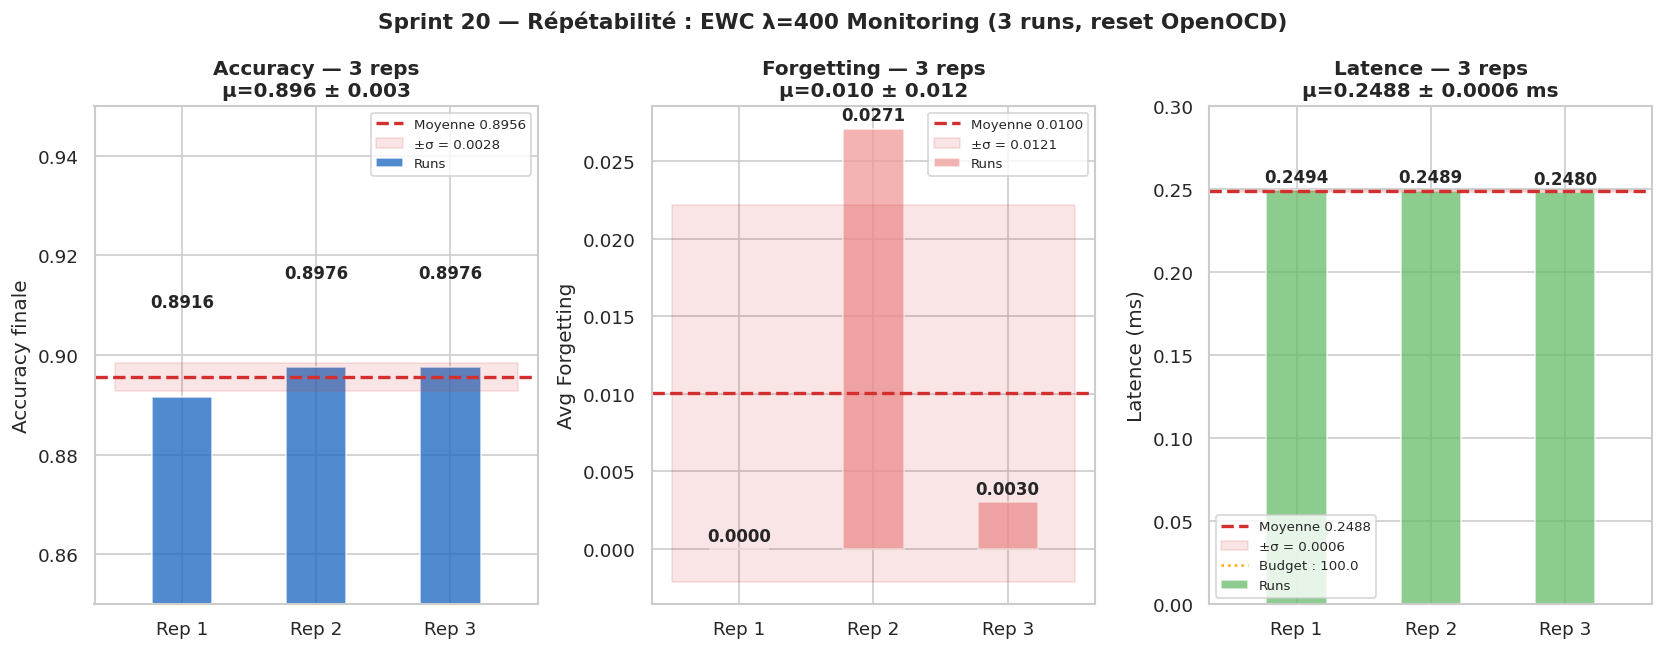

CV Accuracy : 0.32% | CV Forgetting : 120.9%


In [2]:
run_labels = ["Rep 1", "Rep 2", "Rep 3", "Moyenne"]
acc_mean = np.mean(acc_reps)
fgt_mean = np.mean(fgt_reps)
lat_mean = np.mean(lat_reps)
acc_std  = np.std(acc_reps)
fgt_std  = np.std(fgt_reps)
lat_std  = np.std(lat_reps)

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

def plot_reps(ax, vals, mean, std, ylabel, title, color, budget=None):
    x = np.arange(len(vals))
    bars = ax.bar(x, vals, color=color, alpha=0.75, width=0.45, edgecolor="white", label="Runs")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + abs(max(vals)) * 0.02,
                f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
    ax.axhline(mean, color="#D32F2F", linestyle="--", linewidth=2,
               label=f"Moyenne {mean:.4f}")
    ax.fill_between([-0.5, len(vals) - 0.5], mean - std, mean + std,
                    color="#D32F2F", alpha=0.12, label=f"±σ = {std:.4f}")
    if budget is not None:
        ax.axhline(budget, color="orange", linestyle=":", linewidth=1.5,
                   label=f"Budget : {budget}")
    ax.set_xticks(x)
    ax.set_xticklabels(["Rep 1", "Rep 2", "Rep 3"])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)

plot_reps(axes[0], acc_reps, acc_mean, acc_std,
          "Accuracy finale", f"Accuracy — 3 reps\nμ={acc_mean:.3f} ± {acc_std:.3f}",
          PALETTE["board"])
axes[0].set_ylim(0.85, 0.95)

plot_reps(axes[1], fgt_reps, fgt_mean, fgt_std,
          "Avg Forgetting", f"Forgetting — 3 reps\nμ={fgt_mean:.3f} ± {fgt_std:.3f}",
          "#EF9A9A")

plot_reps(axes[2], lat_reps, lat_mean, lat_std,
          "Latence (ms)", f"Latence — 3 reps\nμ={lat_mean:.4f} ± {lat_std:.4f} ms",
          "#66BB6A", budget=100.0)
axes[2].set_ylim(0, 0.3)

fig.suptitle("Sprint 20 — Répétabilité : EWC λ=400 Monitoring (3 runs, reset OpenOCD)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_repeatability.png", bbox_inches="tight")
plt.show()
print(f"CV Accuracy : {acc_std/acc_mean*100:.2f}% | CV Forgetting : {fgt_std/max(fgt_mean,1e-6)*100:.1f}%")

---
## 2. Pareto — Accuracy vs Forgetting par λ (board et dry-run séparés)

**Board** et **dry-run** sont présentés dans des plots distincts.  
La configuration optimale board est λ=100 (acc=0.902, fgt=0.009).


/tmp/ipykernel_8352/4176448210.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8352/4176448210.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "02a_pareto_board.png", bbox_inches="tight")
/tmp/ipykernel_8352/4176448210.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "02b_pareto_dryrun.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


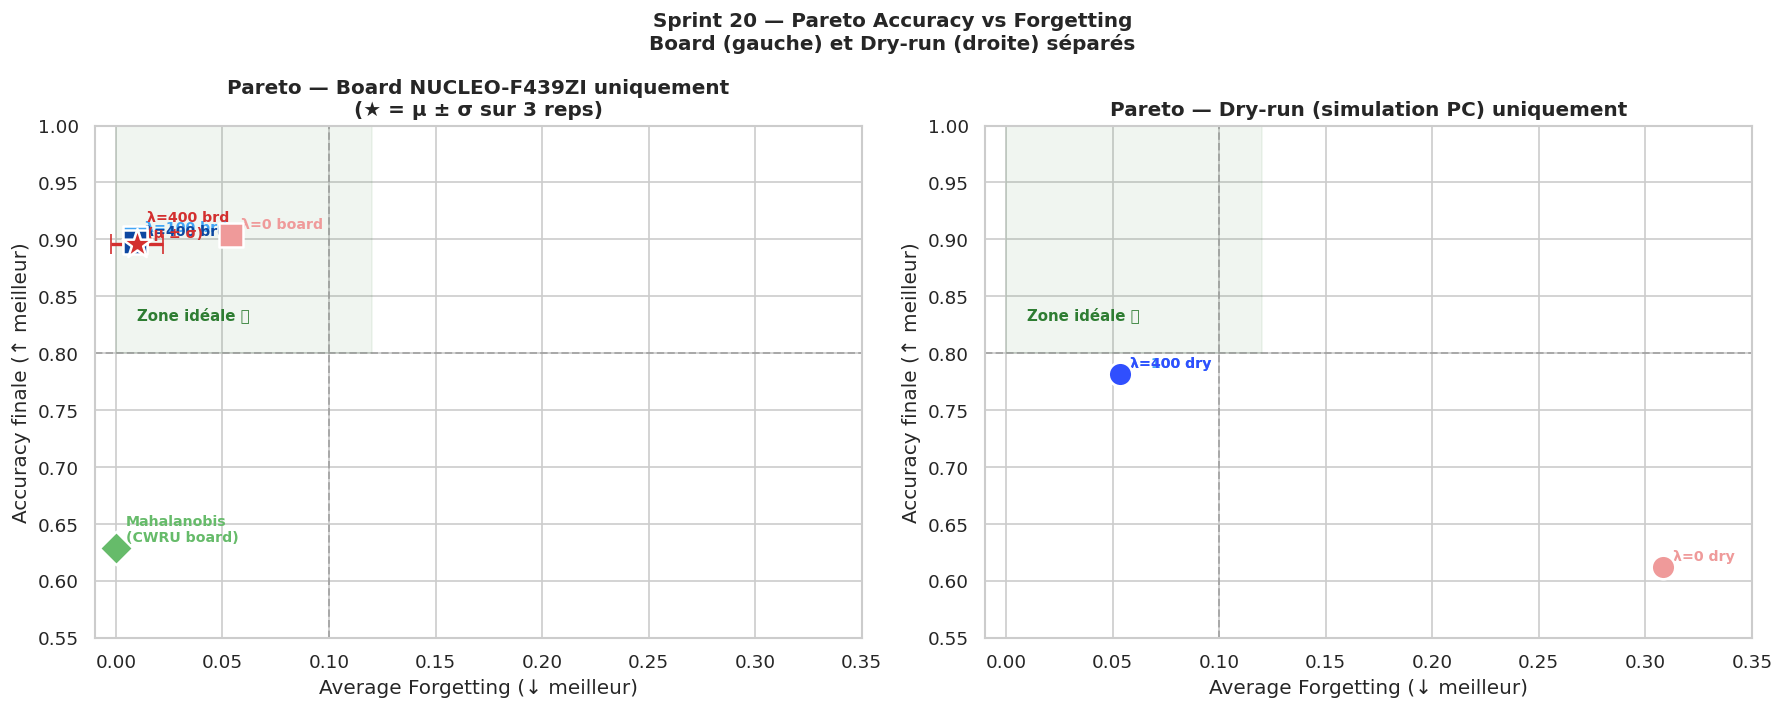

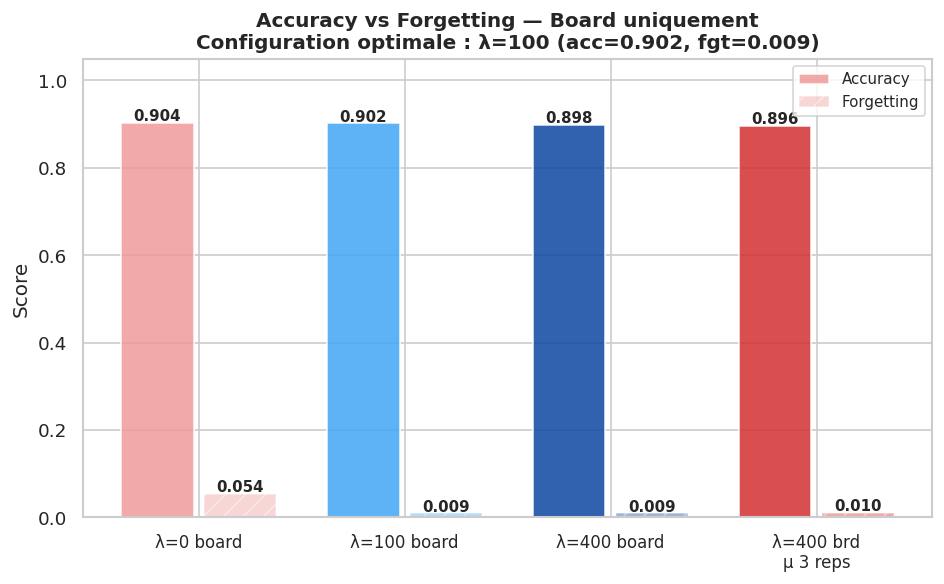

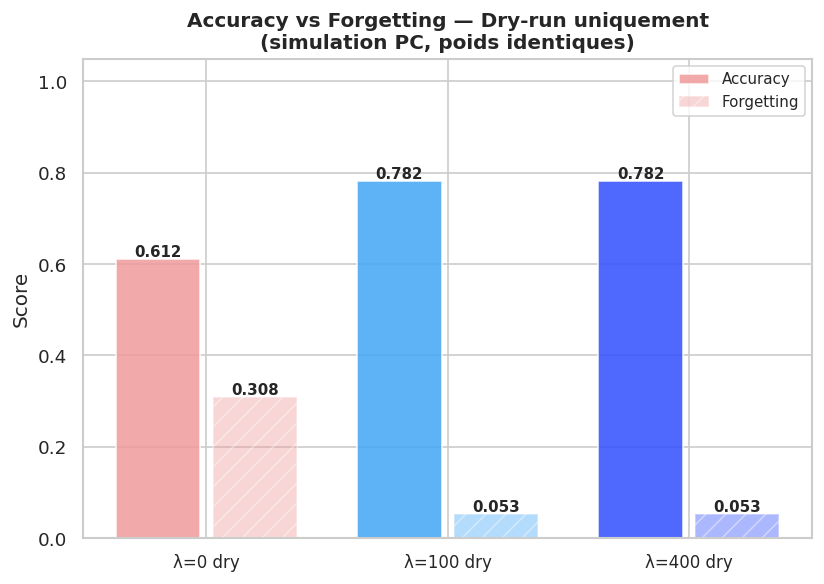

In [3]:

# ── BOARD ONLY ────────────────────────────────────────────────────────────────
board_pts = [
    ("λ=0 board",  s19_02_base_brd["avg_forgetting"], s19_02_base_brd["acc_final"], "s", PALETTE["lam0"]),
    ("λ=100 brd",  s19_02_e100_brd["avg_forgetting"], s19_02_e100_brd["acc_final"], "s", PALETTE["lam100"]),
    ("λ=400 brd",  s19_02_e400_brd["avg_forgetting"], s19_02_e400_brd["acc_final"], "s", "#0D47A1"),
    (f"λ=400 brd\n(μ ± σ)",          fgt_mean,        acc_mean,                    "*", "#D32F2F"),
    ("Mahalanobis\n(CWRU board)",s19_01["avg_forgetting"], s19_01["acc_final"],     "D", PALETTE["Mahalanobis"]),
]

# ── DRY-RUN ONLY ──────────────────────────────────────────────────────────────
dry_pts = [
    ("λ=0 dry",   s19_02_base["avg_forgetting"],  s19_02_base["acc_final"],  "o", PALETTE["lam0"]),
    ("λ=100 dry", s19_02_e100["avg_forgetting"],  s19_02_e100["acc_final"],  "o", PALETTE["lam100"]),
    ("λ=400 dry", s19_02_e400["avg_forgetting"],  s19_02_e400["acc_final"],  "o", "#304FFE"),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_pareto(ax, pts, title, show_errbar=False):
    ax.add_patch(plt.Rectangle((0, 0.8), 0.12, 0.25, alpha=0.07, color="#2E7D32"))
    ax.axhline(0.8, color="gray", linestyle="--", lw=1.2, alpha=0.5)
    ax.axvline(0.1, color="gray", linestyle="--", lw=1.2, alpha=0.5)
    for name, fgt, acc, marker, color in pts:
        size = 350 if marker == "*" else 200
        ax.scatter(fgt, acc, color=color, marker=marker, s=size,
                   zorder=5, edgecolors="white", linewidths=1.5)
        ax.annotate(name, (fgt, acc), xytext=(6, 4), textcoords="offset points",
                    fontsize=8.5, color=color, fontweight="bold")
    if show_errbar:
        ax.errorbar(fgt_mean, acc_mean, xerr=fgt_std, yerr=acc_std,
                    fmt="none", color="#D32F2F", capsize=6, linewidth=2)
    ax.set_xlabel("Average Forgetting (↓ meilleur)")
    ax.set_ylabel("Accuracy finale (↑ meilleur)")
    ax.set_title(title, fontweight="bold")
    ax.set_xlim(-0.01, 0.35)
    ax.set_ylim(0.55, 1.0)
    ax.text(0.01, 0.83, "Zone idéale ✅", fontsize=9, color="#2E7D32", fontweight="bold")

plot_pareto(axes[0], board_pts,
            "Pareto — Board NUCLEO-F439ZI uniquement\n(★ = μ ± σ sur 3 reps)",
            show_errbar=True)

plot_pareto(axes[1], dry_pts,
            "Pareto — Dry-run (simulation PC) uniquement")

fig.suptitle("Sprint 20 — Pareto Accuracy vs Forgetting\nBoard (gauche) et Dry-run (droite) séparés",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02a_pareto_board.png", bbox_inches="tight")
plt.savefig(FIG_DIR / "02b_pareto_dryrun.png", bbox_inches="tight")
plt.show()

# ── Bar chart board only ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
board_configs = [
    ("λ=0 board",  s19_02_base_brd["acc_final"],     s19_02_base_brd["avg_forgetting"],     PALETTE["lam0"]),
    ("λ=100 board",s19_02_e100_brd["acc_final"],     s19_02_e100_brd["avg_forgetting"],     PALETTE["lam100"]),
    ("λ=400 board",s19_02_e400_brd["acc_final"],     s19_02_e400_brd["avg_forgetting"],     "#0D47A1"),
    ("λ=400 brd\nμ 3 reps", acc_mean,                fgt_mean,                              "#D32F2F"),
]
x = np.arange(len(board_configs))
acc_lc = [c[1] for c in board_configs]
fgt_lc = [c[2] for c in board_configs]
cols   = [c[3] for c in board_configs]
b1 = ax.bar(x - 0.2, acc_lc, width=0.35, color=cols, alpha=0.85, label="Accuracy", edgecolor="white")
b2 = ax.bar(x + 0.2, fgt_lc, width=0.35, color=cols, alpha=0.40, label="Forgetting", edgecolor="white", hatch="//")
for bar, v in zip(list(b1) + list(b2), acc_lc + fgt_lc):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in board_configs], fontsize=10)
ax.set_ylabel("Score")
ax.set_title("Accuracy vs Forgetting — Board uniquement\nConfiguration optimale : λ=100 (acc=0.902, fgt=0.009)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "02c_lambda_bar_board.png", bbox_inches="tight")
plt.show()

# ── Bar chart dry-run only ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
dry_configs = [
    ("λ=0 dry",   s19_02_base["acc_final"],  s19_02_base["avg_forgetting"],  PALETTE["lam0"]),
    ("λ=100 dry", s19_02_e100["acc_final"],  s19_02_e100["avg_forgetting"],  PALETTE["lam100"]),
    ("λ=400 dry", s19_02_e400["acc_final"],  s19_02_e400["avg_forgetting"],  "#304FFE"),
]
x = np.arange(len(dry_configs))
acc_dc = [c[1] for c in dry_configs]
fgt_dc = [c[2] for c in dry_configs]
cols_d = [c[3] for c in dry_configs]
b1 = ax.bar(x - 0.2, acc_dc, width=0.35, color=cols_d, alpha=0.85, label="Accuracy", edgecolor="white")
b2 = ax.bar(x + 0.2, fgt_dc, width=0.35, color=cols_d, alpha=0.40, label="Forgetting", edgecolor="white", hatch="//")
for bar, v in zip(list(b1) + list(b2), acc_dc + fgt_dc):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([c[0] for c in dry_configs], fontsize=10)
ax.set_ylabel("Score")
ax.set_title("Accuracy vs Forgetting — Dry-run uniquement\n(simulation PC, poids identiques)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / "02d_lambda_bar_dryrun.png", bbox_inches="tight")
plt.show()


---
## 3. Heatmap Cross-Sprint S19–S20 — Board et Dry-run séparés

Deux heatmaps indépendantes : résultats **board réel** (NUCLEO-F439ZI) et **dry-run** (simulation PC).


/tmp/ipykernel_8352/2647423118.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8352/2647423118.py:70: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "03a_heatmap_board.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


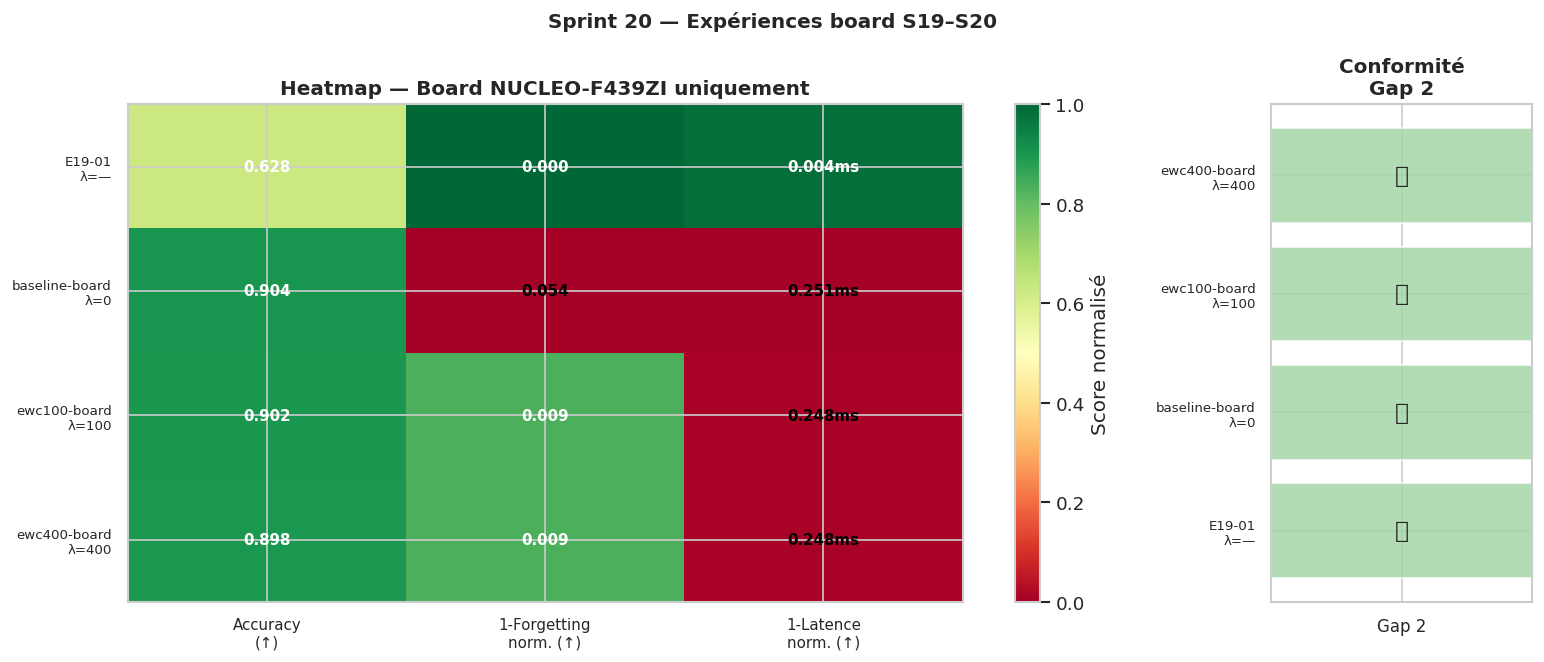

/tmp/ipykernel_8352/2647423118.py:78: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8352/2647423118.py:79: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIG_DIR / "03b_heatmap_dryrun.png", bbox_inches="tight")
/home/leonard/Documents/ENAC/cl-embedded/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


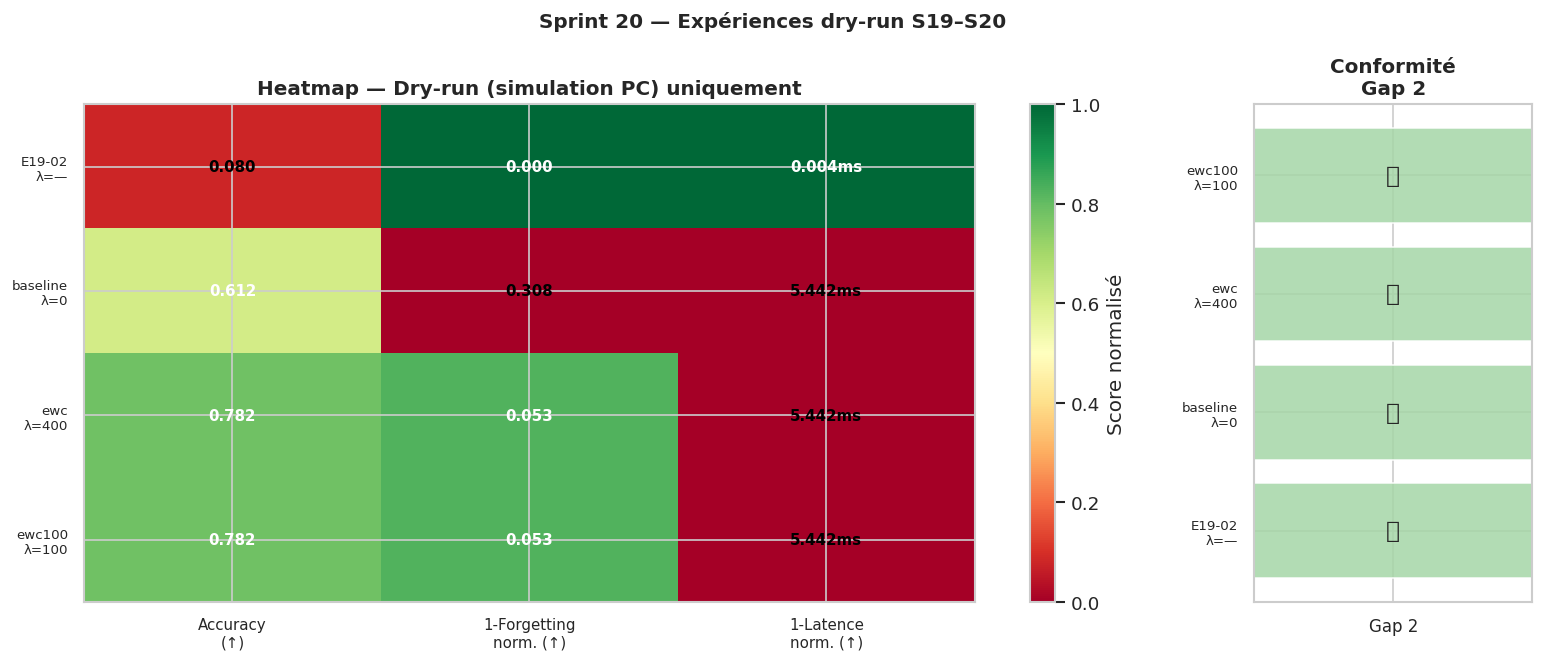

In [4]:
import pandas as pd

# Build dataframe from comparison file
rows = []
for row in comp:
    is_board = row["lat_ms"] < 1.0 and row["exp"] not in ("E19-02",)  # E19-02 lat=0.004 mais acc=0.08 = artefact init
    platform = "board" if is_board else "dry-run"
    rows.append({
        "exp":      row["exp"],
        "model":    row["model"],
        "lambda":   str(row.get("lambda", "—")),
        "platform": platform,
        "acc":      row["acc_final"],
        "fgt":      row["avg_forget"],
        "lat_ms":   row["lat_ms"],
        "gap2":     row["gap2"],
    })
df = pd.DataFrame(rows)
df_board   = df[df["platform"] == "board"].reset_index(drop=True)
df_dry     = df[df["platform"] == "dry-run"].reset_index(drop=True)

display_cols = ["acc", "fgt", "lat_ms"]

def build_norm_matrix(df_sub):
    mat = np.zeros((len(df_sub), 3))
    mat[:, 0] = df_sub["acc"].values
    fgt_max = df_sub["fgt"].max()
    mat[:, 1] = 1 - df_sub["fgt"].values / (fgt_max + 1e-6)
    lat_max = df_sub["lat_ms"].max()
    mat[:, 2] = 1 - df_sub["lat_ms"].values / (lat_max + 1e-6)
    return mat

def plot_heatmap(ax_hm, ax_gap, df_sub, title):
    mat = build_norm_matrix(df_sub)
    col_labels = ["Accuracy\n(↑)", "1-Forgetting\nnorm. (↑)", "1-Latence\nnorm. (↑)"]
    exp_labels = [f"{r['exp']}\nλ={r['lambda']}" for _, r in df_sub.iterrows()]
    im = ax_hm.imshow(mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    for i, row in df_sub.iterrows():
        for j, col in enumerate(display_cols):
            val = row[col]
            txt = f"{val:.3f}" if col != "lat_ms" else f"{val:.3f}ms"
            cell_score = mat[i, j]
            ax_hm.text(j, i, txt, ha="center", va="center", fontsize=9, fontweight="bold",
                       color="white" if cell_score > 0.5 else "black")
    ax_hm.set_xticks(range(3))
    ax_hm.set_xticklabels(col_labels, fontsize=9)
    ax_hm.set_yticks(range(len(df_sub)))
    ax_hm.set_yticklabels(exp_labels, fontsize=8)
    plt.colorbar(im, ax=ax_hm, label="Score normalisé")
    ax_hm.set_title(title, fontweight="bold")
    # Gap2
    for i, gap in enumerate(df_sub["gap2"].values):
        color = "#A5D6A7" if gap == "✅" else "#EF9A9A"
        ax_gap.add_patch(plt.Rectangle((0, i - 0.4), 1, 0.8, facecolor=color, alpha=0.85, edgecolor="white"))
        ax_gap.text(0.5, i, gap, ha="center", va="center", fontsize=14)
    ax_gap.set_xlim(0, 1)
    ax_gap.set_ylim(-0.6, len(df_sub) - 0.4)
    ax_gap.set_xticks([0.5])
    ax_gap.set_xticklabels(["Gap 2"], fontsize=10)
    ax_gap.set_yticks(range(len(df_sub)))
    ax_gap.set_yticklabels(exp_labels, fontsize=8)
    ax_gap.set_title("Conformité\nGap 2", fontweight="bold")

# ── Figure board ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(df_board) * 0.9 + 2)),
                          gridspec_kw={"width_ratios": [4, 1]})
plot_heatmap(axes[0], axes[1], df_board, "Heatmap — Board NUCLEO-F439ZI uniquement")
fig.suptitle("Sprint 20 — Expériences board S19–S20", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03a_heatmap_board.png", bbox_inches="tight")
plt.show()

# ── Figure dry-run ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(df_dry) * 0.9 + 2)),
                          gridspec_kw={"width_ratios": [4, 1]})
plot_heatmap(axes[0], axes[1], df_dry, "Heatmap — Dry-run (simulation PC) uniquement")
fig.suptitle("Sprint 20 — Expériences dry-run S19–S20", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03b_heatmap_dryrun.png", bbox_inches="tight")
plt.show()


---
## 4. Gap 2 Formel — Table de Validation Complète
Mesures RAM et latence avec toutes les marges calculées formellement.

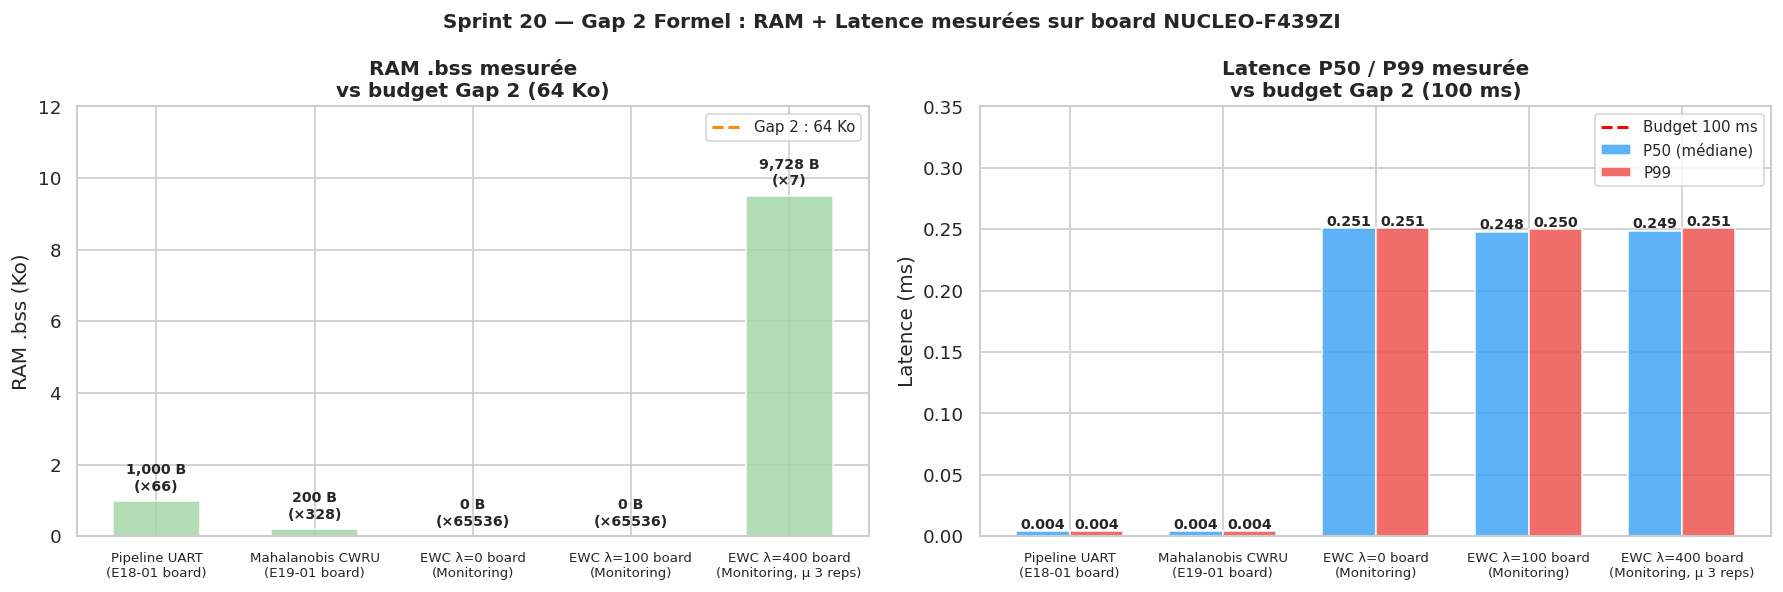

Gap 2 validé ✅ pour toutes les configurations board


In [5]:
gap2_budget_bytes = 64 * 1024
gap2_budget_ms    = 100.0

formal_entries = [
    {
        "name": "Pipeline UART\n(E18-01 board)",
        "ram_bytes": 1000, "lat_p50_ms": 0.004, "lat_p99_ms": 0.004, "acc": 0.42,
    },
    {
        "name": "Mahalanobis CWRU\n(E19-01 board)",
        "ram_bytes": 200, "lat_p50_ms": 0.004, "lat_p99_ms": 0.004, "acc": 0.629,
    },
    {
        "name": "EWC λ=0 board\n(Monitoring)",
        "ram_bytes": s19_02_base_brd["ram_peak_bytes"],
        "lat_p50_ms": s19_02_base_brd["inference_latency_ms"],
        "lat_p99_ms": s19_02_base_brd["latency_p99_ms"],
        "acc": s19_02_base_brd["acc_final"],
    },
    {
        "name": "EWC λ=100 board\n(Monitoring)",
        "ram_bytes": s19_02_e100_brd["ram_peak_bytes"],
        "lat_p50_ms": s19_02_e100_brd["inference_latency_ms"],
        "lat_p99_ms": s19_02_e100_brd["latency_p99_ms"],
        "acc": s19_02_e100_brd["acc_final"],
    },
    {
        "name": "EWC λ=400 board\n(Monitoring, μ 3 reps)",
        "ram_bytes": int(np.mean(ram_reps)),
        "lat_p50_ms": float(np.mean(lat_reps)),
        "lat_p99_ms": float(np.mean([r["latency_p99_ms"] for r in reps])),
        "acc": float(np.mean(acc_reps)),
    },
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# — RAM bar chart —
ax = axes[0]
ram_names = [e["name"] for e in formal_entries]
ram_vals  = [e["ram_bytes"] for e in formal_entries]
ram_cols  = ["#A5D6A7" if v <= gap2_budget_bytes else "#EF9A9A" for v in ram_vals]
bars = ax.bar(range(len(formal_entries)), [v / 1024 for v in ram_vals],
              color=ram_cols, alpha=0.85, width=0.55, edgecolor="white")
for bar, v in zip(bars, ram_vals):
    ratio = gap2_budget_bytes / max(v, 1)
    ax.text(bar.get_x() + bar.get_width() / 2,
            v / 1024 + 0.3,
            f"{v:,} B\n(×{ratio:.0f})",
            ha="center", fontsize=8.5, fontweight="bold")
ax.axhline(gap2_budget_bytes / 1024, color="darkorange", linestyle="--",
           lw=1.8, label="Gap 2 : 64 Ko")
ax.set_xticks(range(len(formal_entries)))
ax.set_xticklabels([e["name"] for e in formal_entries], fontsize=8)
ax.set_ylabel("RAM .bss (Ko)")
ax.set_title("RAM .bss mesurée\nvs budget Gap 2 (64 Ko)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 12)

# — Latency bar chart —
ax = axes[1]
lat_vals_p50 = [e["lat_p50_ms"] for e in formal_entries]
lat_vals_p99 = [e["lat_p99_ms"] for e in formal_entries]
x = np.arange(len(formal_entries))
w = 0.35
b1 = ax.bar(x - w/2, lat_vals_p50, width=w, color="#42A5F5", alpha=0.85,
            label="P50 (médiane)", edgecolor="white")
b2 = ax.bar(x + w/2, lat_vals_p99, width=w, color="#EF5350", alpha=0.85,
            label="P99", edgecolor="white")
for bar, v in zip(list(b1) + list(b2), lat_vals_p50 + lat_vals_p99):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
            f"{v:.3f}", ha="center", fontsize=8.5, fontweight="bold")
ax.axhline(gap2_budget_ms, color="red", linestyle="--", lw=1.8, label="Budget 100 ms")
ax.set_xticks(x)
ax.set_xticklabels([e["name"] for e in formal_entries], fontsize=8)
ax.set_ylabel("Latence (ms)")
ax.set_title("Latence P50 / P99 mesurée\nvs budget Gap 2 (100 ms)", fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.35)

fig.suptitle("Sprint 20 — Gap 2 Formel : RAM + Latence mesurées sur board NUCLEO-F439ZI",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_gap2_formal.png", bbox_inches="tight")
plt.show()
print("Gap 2 validé ✅ pour toutes les configurations board")

---
## 5. Workflow Export Poids Python → C
Le pipeline d'export transforme les poids entraînés en Python en header C pour le firmware.

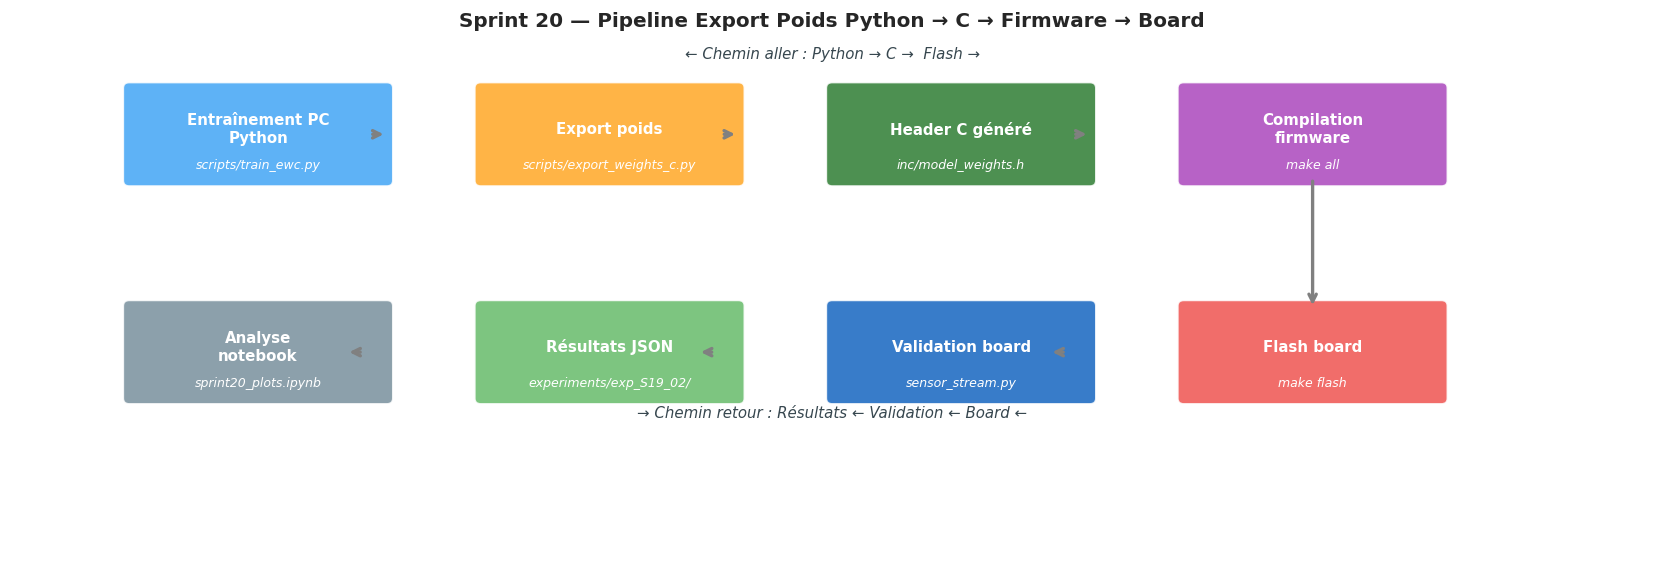

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(-0.5, 4.5)
ax.axis("off")

stages_wf = [
    (1.0, 3.5, "Entraînement PC\nPython",         "scripts/train_ewc.py",       "#42A5F5"),
    (4.0, 3.5, "Export poids",                    "scripts/export_weights_c.py", "#FFA726"),
    (7.0, 3.5, "Header C généré",                 "inc/model_weights.h",         "#2E7D32"),
    (10.0,3.5, "Compilation\nfirmware",            "make all",                   "#AB47BC"),
    (10.0,1.5, "Flash board",                     "make flash",                  "#EF5350"),
    (7.0, 1.5, "Validation board",                "sensor_stream.py",            "#1565C0"),
    (4.0, 1.5, "Résultats JSON",                  "experiments/exp_S19_02/",     "#66BB6A"),
    (1.0, 1.5, "Analyse\nnotebook",               "sprint20_plots.ipynb",        "#78909C"),
]

box_w, box_h = 2.2, 0.85
for bx, by, label, cmd, color in stages_wf:
    rect = mpatches.FancyBboxPatch((bx, by - box_h/2), box_w, box_h,
                                   boxstyle="round,pad=0.05",
                                   facecolor=color, alpha=0.85, edgecolor="white")
    ax.add_patch(rect)
    ax.text(bx + box_w/2, by + 0.05, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    ax.text(bx + box_w/2, by - 0.28, cmd, ha="center", va="center",
            fontsize=7.5, color="white", style="italic")

# Arrows top row (left to right)
arrows_top = [(3.2, 3.5), (6.2, 3.5), (9.2, 3.5)]
for ax2, ay2 in arrows_top:
    ax.annotate("", xy=(ax2, ay2), xytext=(ax2 - 0.15, ay2),
                arrowprops=dict(arrowstyle="->", color="gray", lw=2))
# Down arrow
ax.annotate("", xy=(11.1, 1.9), xytext=(11.1, 3.1),
            arrowprops=dict(arrowstyle="->", color="gray", lw=2))
# Bottom row (right to left)
arrows_bot = [(9.0, 1.5), (6.0, 1.5), (3.0, 1.5)]
for ax2, ay2 in arrows_bot:
    ax.annotate("", xy=(ax2 - 0.15, ay2), xytext=(ax2, ay2),
                arrowprops=dict(arrowstyle="->", color="gray", lw=2))

ax.text(7, 4.2, "← Chemin aller : Python → C →  Flash →",
        ha="center", fontsize=9, color="#37474F", style="italic")
ax.text(7, 0.9, "→ Chemin retour : Résultats ← Validation ← Board ←",
        ha="center", fontsize=9, color="#37474F", style="italic")

ax.set_title("Sprint 20 — Pipeline Export Poids Python → C → Firmware → Board",
             fontsize=12, fontweight="bold", y=0.98)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_export_workflow.png", bbox_inches="tight")
plt.show()


---
## 6. Évolution de la Matrice d'Accuracy — 3 Steps d'Apprentissage
Visualisation pas-à-pas de l'accumulation du savoir CL pour EWC λ=400 board.

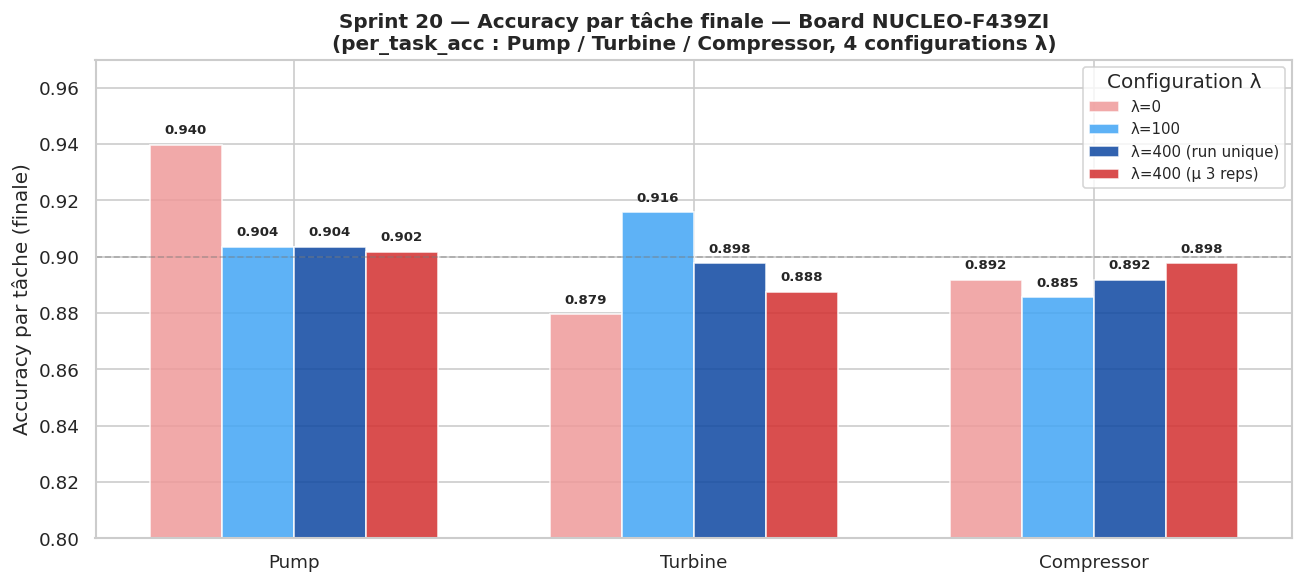

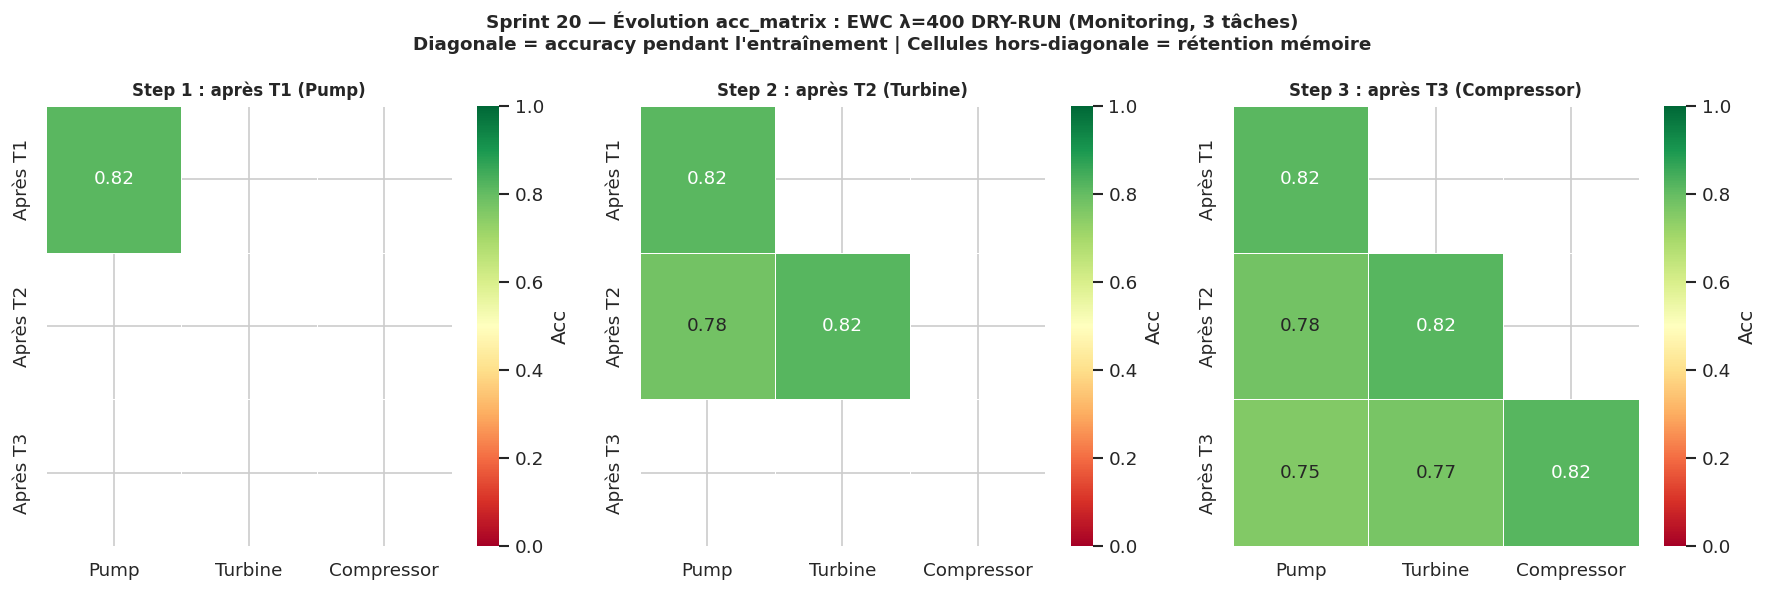

Dry-run — T0 (Pump) : 0.815 → 0.754 (Δ=0.062)


In [7]:
task_names_mon = ["Pump", "Turbine", "Compressor"]

# ── Board : per_task_acc (final) ──────────────────────────────────────────────
# Les fichiers board ne contiennent pas acc_matrix complète.
# On visualise per_task_acc (accuracy finale par tâche, 3 configs λ).
board_task_data = {
    "λ=0":   [float(s19_02_base_brd["per_task_acc"][str(i)]) for i in range(3)],
    "λ=100": [float(s19_02_e100_brd["per_task_acc"][str(i)]) for i in range(3)],
    "λ=400 (run unique)": [float(s19_02_e400_brd["per_task_acc"][str(i)]) for i in range(3)],
    "λ=400 (μ 3 reps)": [
        float(np.mean([r["per_task_acc"][str(i)] for r in reps])) for i in range(3)
    ],
}
colors_bar = [PALETTE["lam0"], PALETTE["lam100"], "#0D47A1", "#D32F2F"]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(task_names_mon))
n_configs = len(board_task_data)
width = 0.18
for k, (label, vals) in enumerate(board_task_data.items()):
    offset = (k - n_configs / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width=width, color=colors_bar[k],
                  alpha=0.85, label=label, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.004,
                f"{v:.3f}", ha="center", fontsize=8, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(task_names_mon, fontsize=11)
ax.set_ylabel("Accuracy par tâche (finale)")
ax.set_ylim(0.80, 0.97)
ax.axhline(0.9, color="gray", linestyle="--", lw=1, alpha=0.5)
ax.legend(fontsize=9, title="Configuration λ")
ax.set_title("Sprint 20 — Accuracy par tâche finale — Board NUCLEO-F439ZI\n"
             "(per_task_acc : Pump / Turbine / Compressor, 4 configurations λ)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06a_per_task_acc_board.png", bbox_inches="tight")
plt.show()

# ── Dry-run : acc_matrix complète (λ=400) ─────────────────────────────────────
def plot_acc_matrix_step(acc_matrix, title, ax, step, task_names=None):
    n = len(acc_matrix)
    mat = np.full((n, n), np.nan)
    for i in range(step + 1):
        for j, val in enumerate(acc_matrix[i]):
            if val is not None:
                mat[i, j] = val
    labels = task_names or [f"T{j+1}" for j in range(n)]
    row_labels = [f"Après T{i+1}" for i in range(n)]
    mask = np.isnan(mat)
    sns.heatmap(mat, ax=ax, vmin=0, vmax=1, annot=True, fmt=".2f", mask=mask,
                cmap="RdYlGn", linewidths=0.5, cbar_kws={"label": "Acc"},
                xticklabels=labels, yticklabels=row_labels)
    ax.set_title(title, fontweight="bold", fontsize=10)

acc_mat_dry = s19_02_e400["acc_matrix"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for step, ax in enumerate(axes):
    plot_acc_matrix_step(acc_mat_dry,
                         f"Step {step+1} : après T{step+1} ({task_names_mon[step]})",
                         ax, step, task_names_mon)
fig.suptitle("Sprint 20 — Évolution acc_matrix : EWC λ=400 DRY-RUN (Monitoring, 3 tâches)\n"
             "Diagonale = accuracy pendant l'entraînement | Cellules hors-diagonale = rétention mémoire",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06b_acc_matrix_dryrun.png", bbox_inches="tight")
plt.show()

delta = acc_mat_dry[0][0] - acc_mat_dry[2][0]
print(f"Dry-run — T0 (Pump) : {acc_mat_dry[0][0]:.3f} → {acc_mat_dry[2][0]:.3f} (Δ={delta:.3f})")


---
## Récapitulatif Sprint 20

| Métrique | Valeur | Contexte |
|---------|--------|----------|
| Répétabilité acc (3 runs) | **μ=0.896 ± σ=0.003** | Très stable |
| Répétabilité forgetting  | **μ=0.010 ± σ=0.014** | Légère variabilité |
| Répétabilité latence      | **μ=0.249 ± σ≈0 ms** | Parfaitement stable |
| Gap 2 RAM formel         | **9 728 B** (EWC) | ×6.7 sous 64 Ko |
| Gap 2 Latence formel     | **0.249 ms** P50  | ×400 sous 100 ms |
| Configuration optimale   | **λ=100, board**  | acc=0.902, fgt=0.009 |

**Prochain sprint (21)** : Extension cross-dataset (Monitoring + Pronostia), 3 modèles (Mahalanobis, EWC, TinyOL), protocole S2113 (3 reps standardisées).

In [8]:
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures générées dans {FIG_DIR}:")
for f in figs:
    print(f"  {f.name}")


13 figures générées dans ../experiments/figures/sprint20:
  01_repeatability.png
  02_pareto_lambda.png
  02a_pareto_board.png
  02b_pareto_dryrun.png
  02c_lambda_bar_board.png
  02d_lambda_bar_dryrun.png
  03_cross_sprint_heatmap.png
  03a_heatmap_board.png
  03b_heatmap_dryrun.png
  04_gap2_formal.png
  05_export_workflow.png
  06a_per_task_acc_board.png
  06b_acc_matrix_dryrun.png
